In [1]:
EXP1 = "G6sulfur"     # subtrahend  (delta = EXP1 - EXP2)
EXP2 = "SSP585"

In [2]:
target_var = "wap"
output_file = "./analysis_transient_data/Sorted_Omega_G6sulfur_and_SSP585.nc"

In [3]:
import numpy as np
import xarray as xr
import cftime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import xarray as xr
from pathlib import Path

import sys
import os

analysis_path = os.path.abspath("../20260112_Basic_Analysis")
sys.path.append(analysis_path)

import myfunctions as mf

#Package to suppress Python warnings
import warnings
warnings.filterwarnings("ignore")


import xesmf as xe
import xarray as xr
import numpy as np

# =========================
# Base CEDA paths
# =========================

CEDA_BASE = Path("/badc/cmip6/data/CMIP6")


#Model Names
MODELS = {
    "UKESM1-0-LL":  {"institution": "MOHC",         "ensemble": "r1i1p1f2",  "grid": "gn",},
    # "CNRM-ESM2-1":  {"institution": "CNRM-CERFACS", "ensemble": "r1i1p1f2",  "grid": "gr",},
    # "MPI-ESM1-2-LR":{"institution": "MPI-M",        "ensemble": "r1i1p1f1",  "grid": "gn",},
    "CESM2-WACCM":  {"institution": "NCAR",         "ensemble": "r1i1p1f1",  "grid": "gn",},
    "IPSL-CM6A-LR": {"institution": "IPSL",         "ensemble": "r1i1p1f1",  "grid": "gr",},
}


# =========================
# Experiment registry
# =========================

EXP_REGISTRY = {
    "piControl": {"project": "CMIP",        "scenario": "piControl"},
    "HIST":      {"project": "CMIP",        "scenario": "historical"},
    "SSP245":    {"project": "ScenarioMIP", "scenario": "ssp245"},
    "SSP585":    {"project": "ScenarioMIP", "scenario": "ssp585"},
    "G6solar":   {"project": "GeoMIP",      "scenario": "G6solar"},
    "G6sulfur":  {"project": "GeoMIP",      "scenario": "G6sulfur"},
}

# Built automatically from EXP1 and EXP2
EXPERIMENTS = {
    EXP1: EXP_REGISTRY[EXP1],
    EXP2: EXP_REGISTRY[EXP2],
}


In [4]:
# ================================================================
# Utility: year-range label per experiment
# ================================================================

def _exp_year_label(exp_name):
    """Return the year-range suffix for an experiment name."""
    if exp_name in ("G6sulfur", "SSP585", "SSP245"):
        return "20212100"
    elif exp_name == "HIST":
        return "19212000"
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'. "
                         "Add it to _exp_year_label().")

def _time_slice(exp_name):
    """Return the (start, end) time slice strings for an experiment."""
    if exp_name in ("G6sulfur", "SSP585", "SSP245"):
        return ("2021-01-01", "2100-12")   # 80 years
    elif exp_name == "HIST":
        return ("1921-01-01", "2000-12")   # 80 years
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'.")


def roll_lon(da):
    """Roll longitude from 0-360 to -180-180."""
    da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180))
    return da.sortby('lon')


def regrid_to_common(da, target_lat=None, target_lon=None):
    """Regrid a DataArray to common lat/lon grid."""
    if target_lat is None:
        target_lat = np.arange(-50, 51, 2.5)
    elif isinstance(target_lat, tuple):
        target_lat = np.arange(target_lat[0], target_lat[1]+1, 2.5)
    elif isinstance(target_lat, (int, float)):
        target_lat = np.arange(-target_lat, target_lat+1, 2.5)

    if target_lon is None:
        target_lon = np.arange(0, 360, 2.5)  # always default to full lon
    elif isinstance(target_lon, tuple):
        target_lon = np.arange(target_lon[0], target_lon[1]+1, 2.5)

    ds_out = xr.Dataset({
        'lat': (['lat'], target_lat),
        'lon': (['lon'], target_lon)
    })

    # Handle both DataSet and DataArray cases
    if isinstance(da, xr.Dataset):
        ds_in = da
    else:
        ds_in = da.to_dataset(name='data')
        
    regridder = xe.Regridder(ds_in, ds_out, method='bilinear', reuse_weights=False)
    return regridder(da) 
    
def climatology_and_uncertainty(da_year, block_size=30):
    """
    da_year: DataArray with dimension 'year'
    Returns:
        clim_mean  : mean climatology (mean of 30-yr block means)
        clim_sd    : std dev across 30-yr block means
        block_means: DataArray of each 30-yr mean
    """

    n_years = da_year.sizes["year"]
    n_blocks = n_years // block_size

    # Trim excess years
    da_trim = da_year.isel(year=slice(0, n_blocks * block_size))

    # Create block index
    block = xr.DataArray(
        np.repeat(np.arange(n_blocks), block_size),
        dims="year",
        coords={"year": da_trim.year},
        name="block"
    )

    # Compute 30-year means
    block_means = (
        da_trim
        .groupby(block)
        .mean(dim="year")*86400
    )

    # Climatological mean (mean of 30-year means)
    clim_mean = block_means.mean(dim="block")

    # Spread across 30-year climatologies
    clim_sd = block_means.std(dim="block")

    return clim_mean, clim_sd, block_means


def load_model_data(base_path, model_name, scenario, mf):
    """
    Generic loader for model data based on model and scenario.

    Parameters
    ----------
    base_path : str or Path
        File path(s) to load
    model_name : str
    scenario : str
    mf : module
        Your module with open_files functions

    Returns
    -------
    xarray.Dataset
    """
    print(str(base_path))

    if model_name == "CESM2-WACCM":
        if scenario == "G6sulfur":
            return mf.open_files_CESM_G6sulfur(base_path)
        elif scenario == "ssp585":
            return mf.open_files_CESM_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))

    elif model_name == "IPSL-CM6A-LR":
        if scenario == "ssp585":
            return mf.open_files_IPSL_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))

    else:
        return mf.open_files(str(base_path))



def load_model_data_alt_path(base_path, project, institution, model_name, scenario, ensemble, grid, mf, var_name=None):
    """
    Generic loader for model data based on model and scenario.
    
    Parameters
    ----------
    base_path : str or Path
        File path(s) to load
    model_name : str
    scenario : str
    mf : module
        Your module with open_files functions
    var_name : str, optional
        Variable name (e.g., 'ua', 'va') to check for downloaded files
    
    Returns
    -------
    xarray.Dataset
    """
    print(str(base_path))
    
    # Check if files exist at base_path, otherwise look in downloaded directory
    base_path = Path(base_path)
    downloaded_base = Path("/home/users/bidyut/data")
    
    # if not base_path.exists() or not list(base_path.glob("*.nc")):
    if not any(base_path.glob("*.nc")):
        # Try downloaded directory
        if var_name:
            # --- special-case ensemble override ---
            if model_name == "CESM2-WACCM":
                ensemble = "r1i1p1f2" if scenario == "G6sulfur" else "r1i1p1f1"
            alt_path = (downloaded_base / project / institution / model_name / scenario / ensemble / "Amon" / 
                       var_name / grid / "latest")
            print(f"Alt path is: {alt_path}")
            if alt_path.exists():
                print(f"  → Using downloaded files at: {alt_path}")
                base_path = alt_path
    
    if model_name == "CESM2-WACCM":
        if scenario == "G6sulfur":
            return mf.open_files_CESM_G6sulfur(base_path)
        elif scenario == "ssp585":
            return mf.open_files_CESM_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))
    elif model_name == "IPSL-CM6A-LR":
        if scenario == "ssp585":
            return mf.open_files_IPSL_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))
    else:
        return mf.open_files(str(base_path))


def roll_and_regrid(varname):
    return roll_lon(regrid_to_common(varname, target_lat=30))

def roll_and_regrid_3d(ds, target_lat=30):
    """Roll and regrid, handling both 2D and 3D data."""
    ds = roll_lon(ds)
    
    if 'plev' in ds.dims or 'lev' in ds.dims:
        lev_dim = 'plev' if 'plev' in ds.dims else 'lev'
        regridded_levels = []
        for lev_val in ds[lev_dim].values:
            level_data = ds.sel({lev_dim: lev_val})
            regridded = regrid_to_common(level_data, target_lat=target_lat)
            regridded_levels.append(regridded)
        return xr.concat(regridded_levels, dim=lev_dim)
    else:
        return regrid_to_common(ds, target_lat=target_lat)

In [5]:
def sort_profile(ds_wap, ds_profile, percentiles=np.arange(0, 101, 1)):
    """
    Sort vertical profiles by 500 hPa vertical velocity (w500) from low to high.
    
    For each month (1-12), sorts all spatial points by their w500 value,
    then computes the mean profile for each percentile bin.
    
    Parameters
    ----------
    ds_wap : xr.Dataset or xr.DataArray
        Vertical velocity (wap) with dimensions (time, plev, lat, lon)
    ds_profile : xr.Dataset or xr.DataArray
        Profile variable to sort (e.g., ta, hus) with dimensions (time, plev, lat, lon)
    percentiles : array-like, default np.arange(0, 101, 1)
        Percentile bins to compute (0-100). Default is 1% bins.
    
    Returns
    -------
    xr.Dataset
        Dataset with dimensions (month, percentile, plev) containing:
        - 'sorted_profile': mean profile for each percentile bin
        - 'w500_percentile': w500 value at each percentile
        - 'count': number of points in each percentile bin
    """
    import numpy as np
    import xarray as xr
    
    # Extract variables if Datasets
    if isinstance(ds_wap, xr.Dataset):
        wap = ds_wap['wap']
    else:
        wap = ds_wap
    
    if isinstance(ds_profile, xr.Dataset):
        # Get first data variable (could be ta, hus, etc.)
        profile_var_name = list(ds_profile.data_vars)[0]
        profile = ds_profile[profile_var_name]
    else:
        profile = ds_profile
        profile_var_name = profile.name or 'profile'

    # ** Align time coordinates**
    common_times = np.intersect1d(wap.time.values, profile.time.values)
    wap = wap.sel(time=common_times)
    profile = profile.sel(time=common_times)
    
    print(f"  Aligned to {len(common_times)} common time steps")
    
    # Select 500 hPa
    w500 = wap.sel(plev=50000, method='nearest')
    
    # Get months
    months = w500.time.dt.month.values
    unique_months = np.arange(1, 13)
    
    # Pressure levels - check different 'lev' coordinate names in different models
    if 'plev' in profile.dims:
        plev = profile.plev.values
        plev_name = 'plev'
    elif 'lev' in profile.dims:
        plev = profile.lev.values
        plev_name = 'lev'
    elif 'presnivs' in profile.dims:
        plev = profile.presnivs.values
        plev_name = 'presnivs'
    else:
        raise ValueError(f"No lev or plev. Profile dimensions found: {profile.dims}")
    
    # Initialize output arrays
    n_months = len(unique_months)
    n_percentiles = len(percentiles)
    n_plev = len(plev)
    
    sorted_profiles = np.full((n_months, n_percentiles, n_plev), np.nan)
    w500_percentiles = np.full((n_months, n_percentiles), np.nan)
    counts = np.full((n_months, n_percentiles), 0)
    
    print(f"  Sorting profiles by w500 for {n_months} months...")
    
    for month_idx, month in enumerate(unique_months):
        
        # Select data for this month
        month_mask = months == month
        w500_month = w500.isel(time=month_mask)
        profile_month = profile.isel(time=month_mask)
        
        # Flatten spatial dimensions (time, lat, lon) -> 1D
        w500_flat = w500_month.values.flatten()
        # profile_flat = profile_month.values.reshape(-1, n_plev)  # (N_points, plev)

        # Ensure plev is last dimension before reshape
        profile_reordered = profile_month.transpose('time', 'lat', 'lon', plev_name)
        profile_flat = profile_reordered.values.reshape(-1, n_plev)
        
        # Remove NaN points
        valid_mask = ~np.isnan(w500_flat)
        w500_valid = w500_flat[valid_mask]
        profile_valid = profile_flat[valid_mask, :]
        
        if len(w500_valid) == 0:
            print(f"    Month {month}: No valid data, skipping")
            continue
        
        # Sort by w500
        sort_indices = np.argsort(w500_valid)
        w500_sorted = w500_valid[sort_indices]
        profile_sorted = profile_valid[sort_indices, :]
        
        # # Compute percentile bins
        # percentile_values = np.percentile(w500_sorted, percentiles)
        
        # for p_idx, (p_low, p_high) in enumerate(zip(percentiles[:-1], percentiles[1:])):
            
        #     # Find indices in this percentile range
        #     idx_low = int(np.floor(len(w500_sorted) * p_low / 100))
        #     idx_high = int(np.ceil(len(w500_sorted) * p_high / 100))
            
        #     if idx_high > idx_low:
        #         # Average profile in this percentile bin
        #         sorted_profiles[month_idx, p_idx, :] = np.nanmean(
        #             profile_sorted[idx_low:idx_high, :], axis=0
        #         )
        #         w500_percentiles[month_idx, p_idx] = np.nanmean(
        #             w500_sorted[idx_low:idx_high]
        #         )
        #         counts[month_idx, p_idx] = idx_high - idx_low

        #
        # Compute percentile *values* (thresholds)
        percentile_values = np.percentile(w500_valid, percentiles)
        
        for p_idx in range(len(percentiles) - 1):
        
            p_low_val  = percentile_values[p_idx]
            p_high_val = percentile_values[p_idx + 1]
        
            # Select points in this value-based percentile bin
            if p_idx == 0:
                # Include lowest value explicitly
                bin_mask = (w500_valid >= p_low_val) & (w500_valid <= p_high_val)
            else:
                bin_mask = (w500_valid > p_low_val) & (w500_valid <= p_high_val)
        
            if np.any(bin_mask):
                sorted_profiles[month_idx, p_idx, :] = np.nanmean(
                    profile_valid[bin_mask, :], axis=0
                )
                w500_percentiles[month_idx, p_idx] = np.nanmean(
                    w500_valid[bin_mask]
                )
                counts[month_idx, p_idx] = np.sum(bin_mask)

        
        # Handle 100th percentile separately
        sorted_profiles[month_idx, -1, :] = profile_sorted[-1, :]
        w500_percentiles[month_idx, -1] = w500_sorted[-1]
        counts[month_idx, -1] = 1
        
        print(f"    Month {month:2d}: Sorted {len(w500_valid):6d} points")
    
    # Create output dataset
    ds_out = xr.Dataset(
        {
            'sorted_profile': (['month', 'percentile', 'plev'], sorted_profiles),
            'w500_percentile': (['month', 'percentile'], w500_percentiles),
            'count': (['month', 'percentile'], counts),
        },
        coords={
            'month': unique_months,
            'percentile': percentiles,
            'plev': plev,
        },
        attrs={
            'description': f'Profiles sorted by w500 (low to high) for each month',
            'profile_variable': profile_var_name,
            'percentile_bins': f'{len(percentiles)} bins from {percentiles[0]} to {percentiles[-1]}%',
        }
    )
    
    return ds_out

In [6]:
"""
SORTING SECTION
"""


import os

# output_file = "ConvectiveMassFlux_sorted_G6sulfur_minus_SSP245.nc"
# output_file = "Omega_sorted_G6sulfur_and_SSP245.nc"


if not os.path.exists(output_file):
    print('#'*40)
    print("File does not exist — running code")
    print('#'*40)


    # ================================================================
    # MAIN PROCESSING LOOP
    # ================================================================
    
    all_results = {}
    
    for model_name, model_meta in MODELS.items():
    
        components_by_exp = {}  # Store all components for each experiment
        seasonal_data = {}      # Store seasonal means by year
    
        # ----------------------------
        # 1) LOAD DATA FOR A MODEL : ALL EXPERIMENTS
        # ----------------------------
        for exp, meta in EXPERIMENTS.items():
    
            # --- special-case ensemble override ---
            if model_name == "CESM2-WACCM":
                ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
            else:
                ensemble = model_meta["ensemble"]
    
            def make_base(vname):
                return (
                    CEDA_BASE
                    / meta["project"]
                    / model_meta["institution"]
                    / model_name
                    / meta["scenario"]
                    / ensemble
                    / "Amon"
                    / vname
                    / model_meta["grid"]
                    / "latest"
                )
    

            # target_var = "wap"
            base_wap = make_base("wap")
            base_profile = make_base(target_var)
            
            ####### Handle ALTERNATE base paths ######
            ds_wap = load_model_data_alt_path(base_wap, meta["project"], model_meta["institution"], 
                                              model_name, meta["scenario"], 
                                              ensemble, model_meta["grid"], mf, "wap")
            ds_profile  = load_model_data_alt_path(base_profile, meta["project"], model_meta["institution"], 
                                              model_name, meta["scenario"], 
                                              ensemble, model_meta["grid"], mf, target_var)
            
            # Roll and regrid
            # ds_wap      = roll_and_regrid(ds_wap)          #can I regrid_to_common for Bombardi and Boos boxes?
            # ds_profile  = roll_and_regrid(ds_profile)
            ds_wap = roll_and_regrid_3d(ds_wap, target_lat=30)
            ds_profile = roll_and_regrid_3d(ds_profile, target_lat=30)
            
            print(f"  [{model_name}] {exp}: wap loaded {ds_wap.sizes['time']} months "
                  f"({ds_wap.time.values[0]} → {ds_wap.time.values[-1]})")
            print(f"  [{model_name}] {exp}: {target_var} loaded {ds_profile.sizes['time']} months "
                  f"({ds_profile.time.values[0]} → {ds_profile.time.values[-1]})")

            
            # Calculate sorted profiles
            print(f"  [{model_name}] {exp}: Sorting profiles by w500...")
            sorted_profiles = sort_profile(ds_wap, ds_profile, percentiles=np.arange(0, 101, 1))
            
            # Store for this experiment
            components_by_exp[exp] = sorted_profiles
    
        # After all experiments for this model
        all_results[model_name] = components_by_exp
    
    
    # ================================================================
    # 5) CREATE OUTPUT NETCDF FILE
    # ================================================================
    
    # Stack all models into one dataset
    model_list = []
    for model_name in all_results.keys():
        exp_list = []
        for exp in EXPERIMENTS.keys():
            if exp in all_results[model_name]:
                ds = all_results[model_name][exp]
                ds = ds.expand_dims({'experiment': [exp]})
                exp_list.append(ds)
        
        # Combine experiments for this model
        if exp_list:
            ds_model = xr.concat(exp_list, dim='experiment')
            ds_model = ds_model.expand_dims({'model': [model_name]})
            model_list.append(ds_model)
    
    # Combine all models
    ds_combined = xr.concat(model_list, dim='model')
    
    # Save
    print(f"\nSaving to {output_file}...")
    ds_combined.to_netcdf(output_file)
    print(f"✓ Saved successfully!")
    print(f"  Dimensions: {dict(ds_combined.dims)}")
    print(f"  Variables: {list(ds_combined.data_vars)}")

else:
    print('#'*40)
    print(f"{output_file} already exists — skipping its computation")
    print('#'*40)

########################################
File does not exist — running code
########################################
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/wap/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/wap/gn/latest
  [UKESM1-0-LL] G6sulfur: wap loaded 972 months (2020-01-16 00:00:00 → 2100-12-16 00:00:00)
  [UKESM1-0-LL] G6sulfur: wap loaded 972 months (2020-01-16 00:00:00 → 2100-12-16 00:00:00)
  [UKESM1-0-LL] G6sulfur: Sorting profiles by w500...
  Aligned to 972 common time steps
  Sorting profiles by w500 for 12 months...
    Month  1: Sorted 291600 points
    Month  2: Sorted 291600 points
    Month  3: Sorted 291600 points
    Month  4: Sorted 291600 points
    Month  5: Sorted 291600 points
    Month  6: Sorted 291600 points
    Month  7: Sorted 291600 points
    Month  8: Sorted 291600 points
    Month  9: Sorted 291600 points
    Month 10: Sorted 291600 points
    Month 11: Sorted 291600 points
    Month 12:

## Plotting 

In [7]:
def plot_sorted_profiles_comparison(
    ds_sorted,
    exp1=EXP1,
    exp2=EXP2,
    months=(6, 9),
    percentile_range=(0, 10),
    variable_name='sorted_profile',
    figsize=(10, 6),
    save_fig=False,
    fig_path=None,
    spread=False,
):
    """
    Plot vertical profiles sorted by w500 for two experiments.
    
    Parameters
    ----------
    ds_sorted : xr.Dataset
        Combined sorted profiles dataset with dims (model, experiment, month, percentile, plev)
    exp1 : str
        First experiment name (e.g., 'G6sulfur')
    exp2 : str
        Second experiment name (e.g., 'SSP245')
    months : tuple
        Month range to average (e.g., (6, 9) for JJAS)
    percentile_range : tuple
        Percentile range to select (e.g., (0, 10) for strong ascent, (90, 100) for strong descent)
    variable_name : str
        Variable to plot ('sorted_profile')
    figsize : tuple
        Figure size
    save_fig : bool
        Whether to save figure
    fig_path : str
        Path to save figure
    
    Returns
    -------
    fig, ax
    """
    import numpy as np
    import matplotlib.pyplot as plt
    
    # Select percentile range and months
    # Select percentile range and months
    if months[0] > months[1]:  # Handles wrapping (e.g., NDJF: 11, 12, 1, 2)
        month_mask = (ds_sorted.month >= months[0]) | (ds_sorted.month <= months[1])
        data = ds_sorted[variable_name].where(month_mask, drop=True).sel(
            percentile=slice(percentile_range[0], percentile_range[1])
        )
    else:  # Normal range (e.g., JJAS: 6-9)
        data = ds_sorted[variable_name].sel(
            percentile=slice(percentile_range[0], percentile_range[1]),
            month=slice(months[0], months[1])
        )
    
    # Average over percentiles and months
    data = data.mean(dim=['percentile', 'month'])
    
    # Now data has dims: (model, experiment, plev)
    
    # Select experiments
    data_exp1 = data.sel(experiment=exp1)  # (model, plev)
    data_exp2 = data.sel(experiment=exp2)  # (model, plev)
    
    # Compute multi-model mean and spread
    mean_exp1 = data_exp1.mean(dim='model')
    std_exp1 = data_exp1.std(dim='model')
    
    mean_exp2 = data_exp2.mean(dim='model')
    std_exp2 = data_exp2.std(dim='model')
    
    # Pressure levels (convert Pa to hPa)
    plev = data.plev.values / 100
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot exp1
    ax.plot(mean_exp1, plev, linewidth=2.5, color='red', label=exp1, zorder=3)
    if spread:
        ax.fill_betweenx(plev, mean_exp1 - std_exp1, mean_exp1 + std_exp1,
                         color='red', alpha=0.3, edgecolor='none')
    
    # Plot exp2
    ax.plot(mean_exp2, plev, linewidth=2.5, color='blue', label=exp2, zorder=3)
    if spread:
        ax.fill_betweenx(plev, mean_exp2 - std_exp2, mean_exp2 + std_exp2,
                         color='blue', alpha=0.3, edgecolor='none')
    
    # Formatting
    ax.invert_yaxis()
    # ax.set_yscale('log')
    ax.set_ylabel('Pressure (hPa)', fontsize=12)
    ax.set_xlabel(f'{variable_name.replace("_", " ").title()}', fontsize=12)
    
    # Set y-axis ticks
    ax.set_yticks([1000, 850, 700, 500, 300, 200, 100])
    ax.set_yticklabels(['1000', '850', '700', '500', '300', '200', '100'])
    
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='best', fontsize=11, framealpha=0.9)
    
    # Title
    month_names = {1: 'Jan', 2: 'Feb', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 11: 'Nov', 12: 'Dec'}
    month_str = '-'.join([month_names.get(m, str(m)) for m in range(months[0], months[1]+1)])
    
    if percentile_range[1] <= 50:
        circulation = f'Strong Ascent (w500 percentile {percentile_range[0]}-{percentile_range[1]}%)'
    else:
        circulation = f'Strong Descent (w500 percentile {percentile_range[0]}-{percentile_range[1]}%)'
    
    ax.set_title(
        f'Vertical Profile: {circulation}\n'
        f'{month_str} | Multi-Model Mean ± 1 Std Dev',
        fontsize=12, fontweight='bold'
    )
    
    plt.tight_layout()
    
    if save_fig:
        path = fig_path or f'sorted_profile_{exp1}_vs_{exp2}_p{percentile_range[0]}-{percentile_range[1]}.png'
        fig.savefig(path, dpi=300, bbox_inches='tight')
        print(f"Figure saved → {path}")
    
    plt.show()
    
    return fig, ax

In [21]:
def plot_sorted_profiles_comparison_diff(
    ds_sorted,
    exp1=EXP1,
    exp2=EXP2,
    months=(6, 9),
    percentile_range=(0, 10),
    variable_name='sorted_profile',
    figsize=(10, 6),
    save_fig=False,
    fig_path=None,
    spread=False,
):
    """
    Plot vertical profiles sorted by w500 for two experiments.
    
    Parameters
    ----------
    ds_sorted : xr.Dataset
        Combined sorted profiles dataset with dims (model, experiment, month, percentile, plev)
    exp1 : str
        First experiment name (e.g., 'G6sulfur')
    exp2 : str
        Second experiment name (e.g., 'SSP245')
    months : tuple
        Month range to average (e.g., (6, 9) for JJAS)
    percentile_range : tuple
        Percentile range to select (e.g., (0, 10) for strong ascent, (90, 100) for strong descent)
    variable_name : str
        Variable to plot ('sorted_profile')
    figsize : tuple
        Figure size
    save_fig : bool
        Whether to save figure
    fig_path : str
        Path to save figure
    
    Returns
    -------
    fig, ax
    """
    import numpy as np
    import matplotlib.pyplot as plt
    
    # Select percentile range and months
    # Select percentile range and months
    if months[0] > months[1]:  # Handles wrapping (e.g., NDJF: 11, 12, 1, 2)
        month_mask = (ds_sorted.month >= months[0]) | (ds_sorted.month <= months[1])
        data = ds_sorted[variable_name].where(month_mask, drop=True).sel(
            percentile=slice(percentile_range[0], percentile_range[1])
        )
    else:  # Normal range (e.g., JJAS: 6-9)
        data = ds_sorted[variable_name].sel(
            percentile=slice(percentile_range[0], percentile_range[1]),
            month=slice(months[0], months[1])
        )
    
    # Average over percentiles and months
    data = data.mean(dim=['percentile', 'month'])
    
    # Now data has dims: (model, experiment, plev)
    
    # Select experiments
    data_exp1 = data.sel(experiment=exp1)  # (model, plev)
    data_exp2 = data.sel(experiment=exp2)  # (model, plev)
    
    # Compute per-model differences
    diff = data_exp1 - data_exp2  # (model, plev)
    
    # Multi-model mean and spread of the differences
    mean_diff = diff.mean(dim='model') *1000
    std_diff = diff.std(dim='model') *1000
    
    # Pressure levels (convert Pa to hPa)
    plev = data.plev.values / 100
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot
    ax.plot(mean_diff, plev, linewidth=2.5, color='red', 
            label=f'{exp1} - {exp2}', zorder=3)
    ax.fill_betweenx(plev, mean_diff - std_diff, mean_diff + std_diff,
                     color='red', alpha=0.3, edgecolor='none')

    ax.set_xlim(-5,5)
    
    # Add zero line
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    
    # Formatting
    ax.invert_yaxis()
    # ax.set_yscale('log')
    ax.set_ylabel('Pressure (hPa)', fontsize=12)
    ax.set_xlabel(f'{variable_name.replace("_", " ").title()}', fontsize=12)
    
    # Set y-axis ticks
    ax.set_yticks([1000, 850, 700, 500, 300, 200, 100])
    ax.set_yticklabels(['1000', '850', '700', '500', '300', '200', '100'])
    
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='best', fontsize=11, framealpha=0.9)
    
    # Title
    month_names = {1: 'Jan', 2: 'Feb', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 11: 'Nov', 12: 'Dec'}
    month_str = '-'.join([month_names.get(m, str(m)) for m in range(months[0], months[1]+1)])
    
    if percentile_range[1] <= 50:
        circulation = f'Strong Ascent (w500 percentile {percentile_range[0]}-{percentile_range[1]}%)'
    else:
        circulation = f'Strong Descent (w500 percentile {percentile_range[0]}-{percentile_range[1]}%)'
    
    ax.set_title(
        f'Vertical Profile Difference: {exp1} - {exp2}\n'
        f'{circulation}\n'
        f'{month_str} | Multi-Model Mean ± 1 Std Dev',
        fontsize=12, fontweight='bold'
    )
        
    plt.tight_layout()
    
    if save_fig:
        path = fig_path or f'sorted_profile_{exp1}_vs_{exp2}_p{percentile_range[0]}-{percentile_range[1]}.png'
        fig.savefig(path, dpi=300, bbox_inches='tight')
        print(f"Figure saved → {path}")
    
    plt.show()
    
    return fig, ax

In [22]:
# Load the dataset
ds_sorted = xr.open_dataset(output_file)
# ds_sorted = xr.open_dataset('Omega_sorted_G6sulfur_and_SSP245.nc')

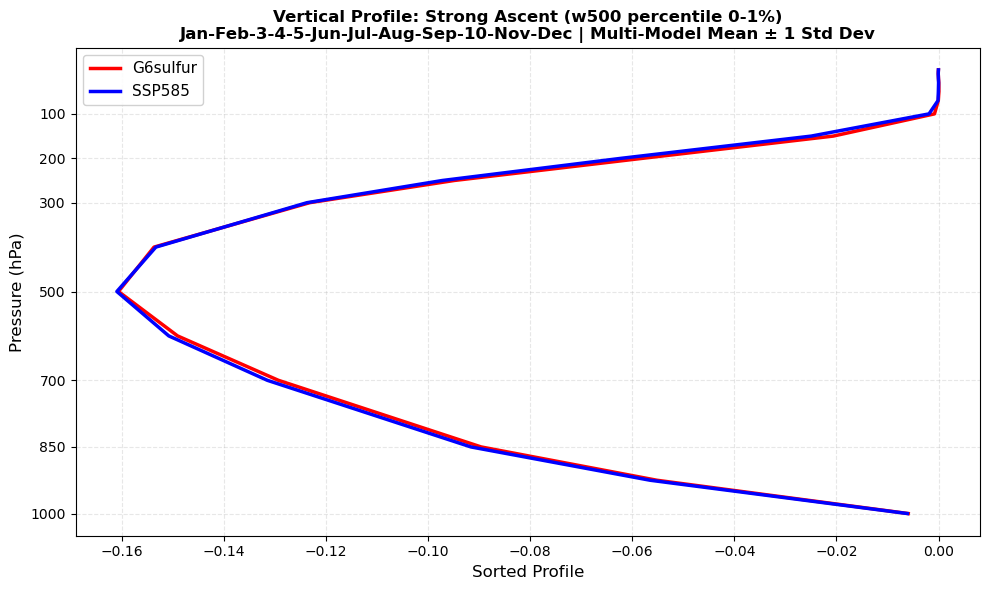

In [23]:
# Strong ascent (lowest 10% of w500, i.e., strongest upward motion)
fig, ax = plot_sorted_profiles_comparison(
    ds_sorted,
    exp1=EXP1,
    exp2=EXP2,
    months=(1, 12),  # JJAS
    percentile_range=(0, 1),  # Strong ascent
    save_fig=False,
    spread=False,
)

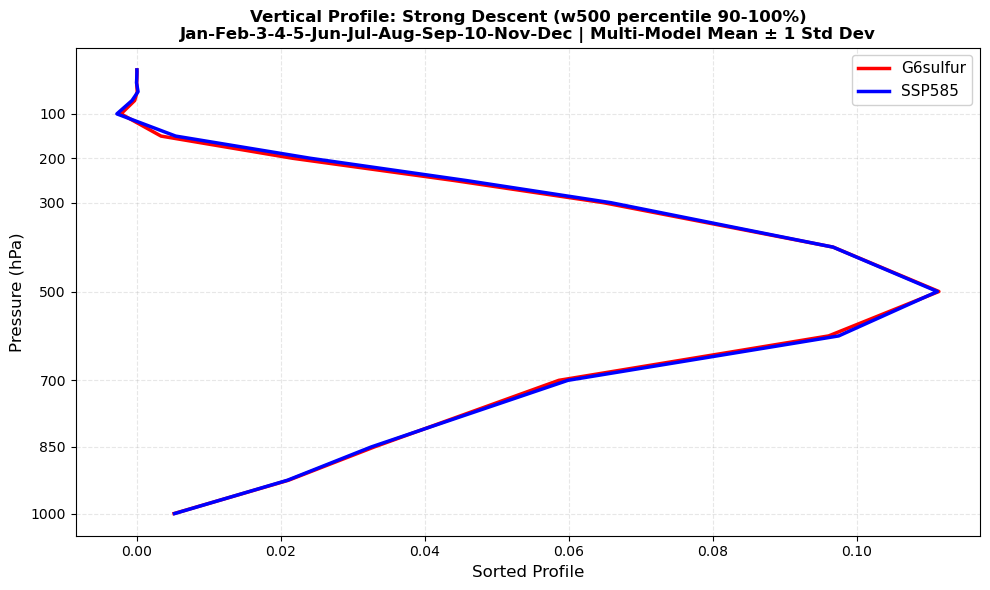

In [24]:
# Strong ascent (highest 10% of w500, i.e., strongest dwownard motion)
fig, ax = plot_sorted_profiles_comparison(
    ds_sorted,
    exp1=EXP1,
    exp2=EXP2,
    months=(1, 12),  # JJAS
    percentile_range=(90, 100),  # Strong ascent
    save_fig=False,
    spread=False,
)

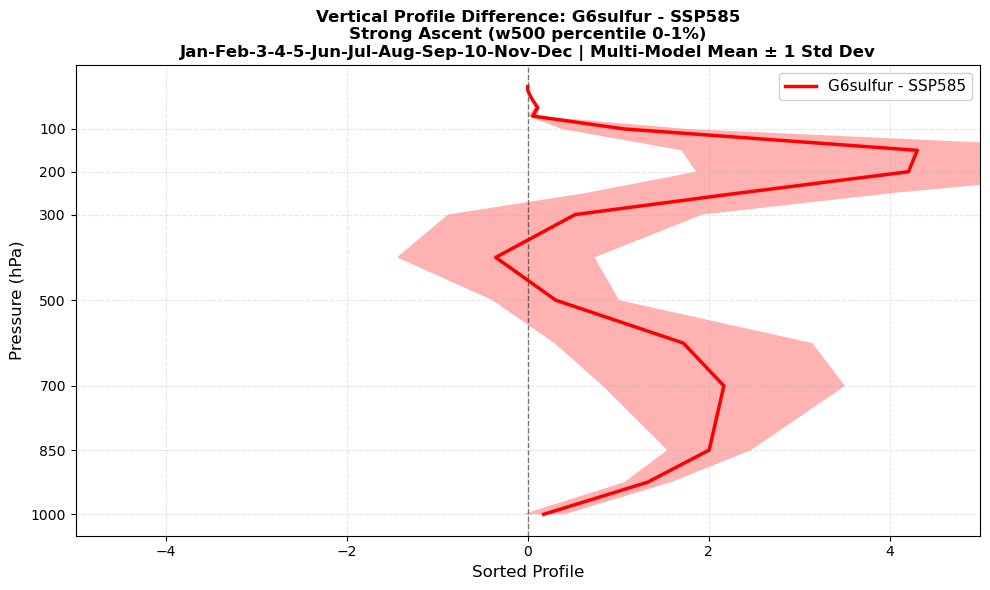

In [25]:
# Strong ascent (lowest 10% of w500, i.e., strongest upward motion)
fig, ax = plot_sorted_profiles_comparison_diff(
    ds_sorted,
    exp1=EXP1,
    exp2=EXP2,
    months=(1, 12),  # JJAS
    percentile_range=(0, 1),  # Strong ascent
    save_fig=False,
    spread=True,
)

In [28]:
def plot_multiple_percentile_ranges_single_panel(
    ds_sorted, 
    exp1, 
    exp2, 
    months, 
    percentile_ranges, 
    colors=None,
    labels=None,
    figsize=(10, 6),
    save_fig=False,
    fig_path=None
):
    """
    Plot multiple percentile ranges on a single panel with different colors.
    
    Parameters
    ----------
    percentile_ranges : list of tuples
        List of (p_low, p_high) percentile ranges, e.g., [(0, 10), (90, 100)]
    colors : list of str, optional
        Colors for each range. Default: ['blue', 'red', 'green', 'purple']
    labels : list of str, optional
        Labels for each range. Auto-generated if None.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    if colors is None:
        colors = ['blue', 'red', 'green', 'purple', 'orange', 'cyan']
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    for idx, perc_range in enumerate(percentile_ranges):
        
        # Select months and percentiles
        if months[0] > months[1]:
            month_mask = (ds_sorted.month >= months[0]) | (ds_sorted.month <= months[1])
            data = ds_sorted['sorted_profile'].where(month_mask, drop=True)
        else:
            data = ds_sorted['sorted_profile'].sel(month=slice(months[0], months[1]))
        
        data = data.mean(dim='month')
        data = data.sel(percentile=slice(perc_range[0], perc_range[1])).mean(dim='percentile')
        
        # Compute differences
        data_exp1 = data.sel(experiment=exp1)
        data_exp2 = data.sel(experiment=exp2)
        diff = data_exp1 - data_exp2
        
        mean_diff = diff.mean(dim='model') * 1000
        std_diff = diff.std(dim='model') * 1000
        
        plev = data.plev.values / 100
        
        # Generate label if not provided
        if labels is None:
            if perc_range[1] <= 50:
                label = f'Strong Ascent (p{perc_range[0]}-{perc_range[1]})'
            else:
                label = f'Strong Descent (p{perc_range[0]}-{perc_range[1]})'
        else:
            label = labels[idx]
        
        color = colors[idx % len(colors)]
        
        # Plot
        ax.plot(mean_diff, plev, linewidth=2.5, color=color, 
                label=label, zorder=3)
        ax.fill_betweenx(plev, mean_diff - std_diff, mean_diff + std_diff,
                         color=color, alpha=0.2, edgecolor='none')
    
    # Zero line
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Formatting
    ax.invert_yaxis()
    ax.set_ylabel('Pressure (hPa)', fontsize=12)
    ax.set_xlabel('Difference (‰)', fontsize=12)
    ax.set_xlim(-5, 5)
    
    # Y-axis ticks
    ax.set_yticks([1000, 850, 700, 500, 300, 200, 100])
    ax.set_yticklabels(['1000', '850', '700', '500', '300', '200', '100'])
    
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='best', fontsize=10, framealpha=0.9)
    
    # Title
    month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 
                   7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
    if months[0] > months[1]:  # Wrapping case
        month_str = '-'.join([month_names.get(m, str(m)) 
                             for m in list(range(months[0], 13)) + list(range(1, months[1]+1))])
    else:
        month_str = '-'.join([month_names.get(m, str(m)) for m in range(months[0], months[1]+1)])
    
    ax.set_title(
        f'Vertical Profile Difference: {exp1} - {exp2}\n'
        f'{month_str} | Multi-Model Mean ± 1 Std Dev',
        fontsize=12, fontweight='bold'
    )
    
    plt.tight_layout()
    
    if save_fig:
        path = fig_path or f'profiles_combined_{exp1}_minus_{exp2}.png'
        fig.savefig(path, dpi=300, bbox_inches='tight')
        print(f"Figure saved → {path}")
    
    plt.show()
    
    return fig, ax

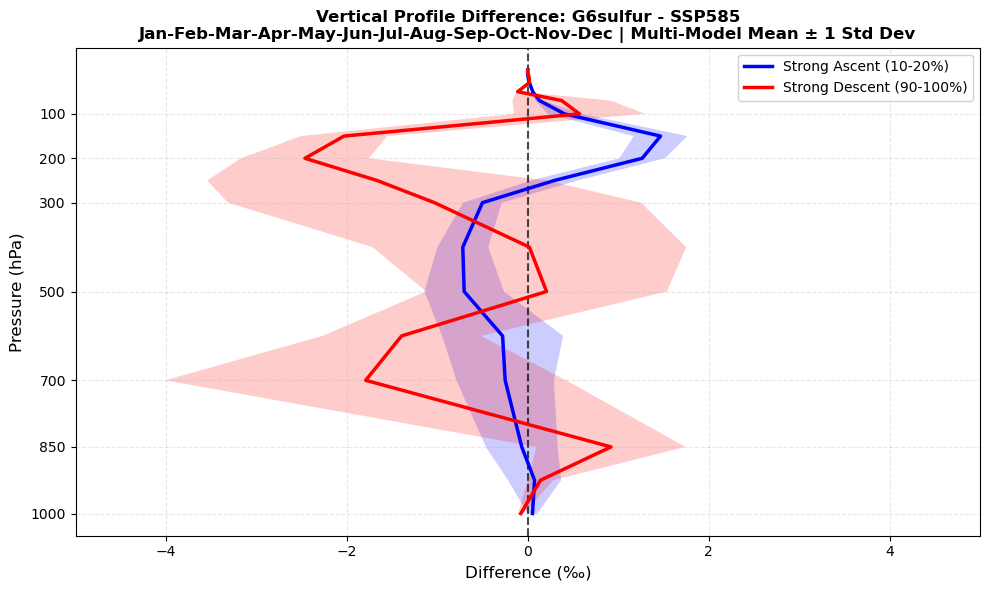

In [29]:
# Plot ascent (blue) and descent (red) on same panel
fig, ax = plot_multiple_percentile_ranges_single_panel(
    ds_sorted,
    exp1=EXP1,
    exp2=EXP2,
    months=(1, 12),  # Annual
    percentile_ranges=[(10, 20), (90, 100)],
    colors=['blue', 'red'],
    labels=['Strong Ascent (10-20%)', 'Strong Descent (90-100%)'],
    save_fig=False
)

In [30]:
def plot_sorted_profiles_comparison_diff_2D(
    ds_sorted,
    exp1=EXP1,
    exp2=EXP2,
    months=(6, 9),
    percentile_range=None,  # Not used for 2D plot
    variable_name='sorted_profile',
    figsize=(15, 4),
    save_fig=False,
    fig_path=None,
    spread=False,
):
    """
    Plot 2D difference of vertical profiles sorted by w500.
    
    X-axis: percentile (0-100)
    Y-axis: pressure level (height)
    Color: difference (exp1 - exp2)
    """
    import numpy as np
    import matplotlib.pyplot as plt
    
    # Select months
    if months[0] > months[1]:  # Handles wrapping (e.g., NDJF: 11, 12, 1, 2)
        month_mask = (ds_sorted.month >= months[0]) | (ds_sorted.month <= months[1])
        data = ds_sorted[variable_name].where(month_mask, drop=True)
    else:  # Normal range (e.g., JJAS: 6-9)
        data = ds_sorted[variable_name].sel(month=slice(months[0], months[1]))
    
    # Average over months
    data = data.mean(dim='month')
    
    # Now data has dims: (model, experiment, percentile, plev)
    
    # Select experiments
    data_exp1 = data.sel(experiment=exp1)  # (model, percentile, plev)
    data_exp2 = data.sel(experiment=exp2)  # (model, percentile, plev)
    
    # Compute per-model differences
    diff = data_exp1 - data_exp2  # (model, percentile, plev)
    
    # Multi-model mean of the differences
    mean_diff = diff.mean(dim='model')  # (percentile, plev)
    std_diff = diff.std(dim='model')    # (percentile, plev)
    
    # Get coordinates
    percentiles = data.percentile.values
    plev = data.plev.values / 100  # Convert Pa to hPa
    
    # Create meshgrid for plotting
    PERC, PLEV = np.meshgrid(percentiles, plev)
    
    # Transpose mean_diff to (plev, percentile) for plotting
    Z = mean_diff.values.T * 1000  # Convert to per mille or adjust units
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Contour plot
    levels = np.linspace(-2.0, 2.0, 21)
    im = ax.contourf(PERC, PLEV, Z, levels=levels, cmap='RdBu_r', extend='both')
    
    # Contour lines
    cs = ax.contour(PERC, PLEV, Z, levels=levels[::2], colors='black', 
                    linewidths=0.5, alpha=0.3)
    
    # Zero contour (bold)
    ax.contour(PERC, PLEV, Z, levels=[0], colors='black', linewidths=1.5)
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02)
    cbar.set_label(f'Δ{variable_name.replace("_", " ").title()} ({exp1} - {exp2})', 
                   fontsize=11)
    
    # Formatting
    ax.invert_yaxis()
    ax.set_ylabel('Pressure (hPa)', fontsize=12)
    ax.set_xlabel('w500 Percentile', fontsize=12)
    
    # Y-axis
    ax.set_yticks([1000, 850, 700, 500, 300, 200, 100])
    ax.set_yticklabels(['1000', '850', '700', '500', '300', '200', '100'])
    
    # X-axis
    ax.set_xlim(0, 100)
    ax.set_xticks(np.arange(0, 101, 10))
    
    # Grid
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Add shading for ascent/descent regions
    ax.axvspan(0, 50, alpha=0.05, color='blue', zorder=0)
    ax.axvspan(50, 100, alpha=0.05, color='red', zorder=0)
    ax.text(15, plev.max()*0.85, 'Ascent', ha='center', fontsize=9, 
            color='blue', alpha=0.7)
    ax.text(75, plev.max()*0.85, 'Descent', ha='center', fontsize=9, 
            color='red', alpha=0.7)
    
    # Title
    month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 
                   10: 'Oct', 11: 'Nov', 12: 'Dec'}
    if months[0] > months[1]:  # Wrapping case
        month_str = '-'.join([month_names.get(m, str(m)) 
                             for m in list(range(months[0], 13)) + list(range(1, months[1]+1))])
    else:
        month_str = '-'.join([month_names.get(m, str(m)) for m in range(months[0], months[1]+1)])
    
    ax.set_title(
        f'Vertical Profile Difference: {exp1} - {exp2}\n'
        f'Sorted by w500 | {month_str} | Multi-Model Mean',
        fontsize=12, fontweight='bold'
    )
    
    plt.tight_layout()
    
    if save_fig:
        path = fig_path or f'sorted_profile_2D_{exp1}_minus_{exp2}_{month_str}.png'
        fig.savefig(path, dpi=300, bbox_inches='tight')
        print(f"Figure saved → {path}")
    
    plt.show()
    
    return fig, ax, mean_diff, std_diff

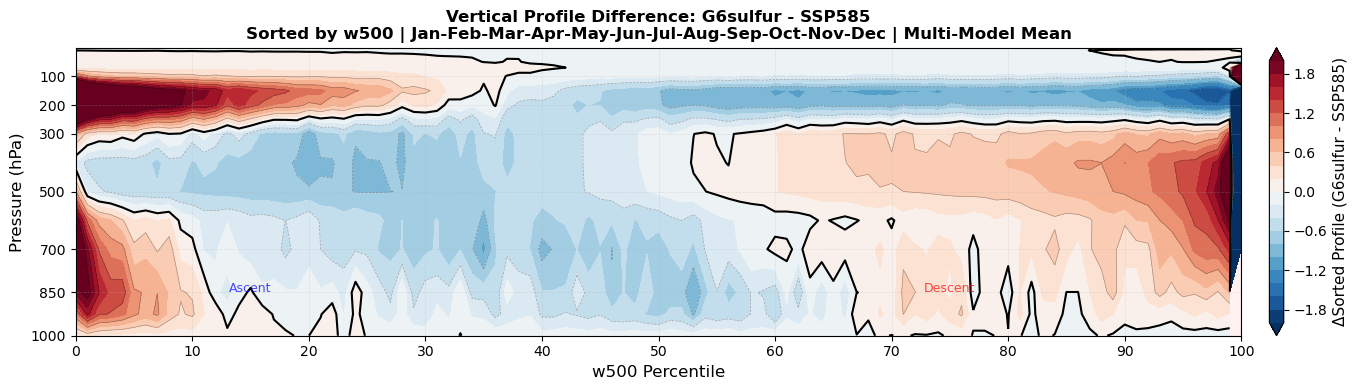

In [31]:
# Plot 2D difference for JJAS
fig, ax, mean, std = plot_sorted_profiles_comparison_diff_2D(
    ds_sorted,
    exp1=EXP1,
    exp2=EXP2,
    months=(1, 12),
    save_fig=False
)

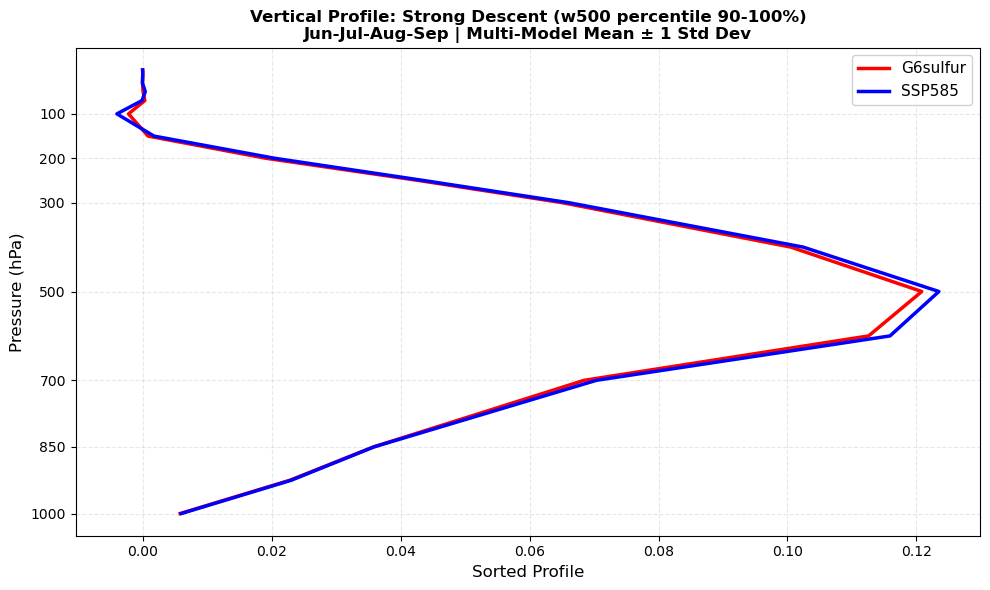

In [32]:
# Strong descent (highest 10% of w500, i.e., strongest downward motion)
fig, ax = plot_sorted_profiles_comparison(
    ds_sorted,
    exp1=EXP1,
    exp2=EXP2,
    months=(6, 9),
    percentile_range=(90, 100),  # Strong descent
)

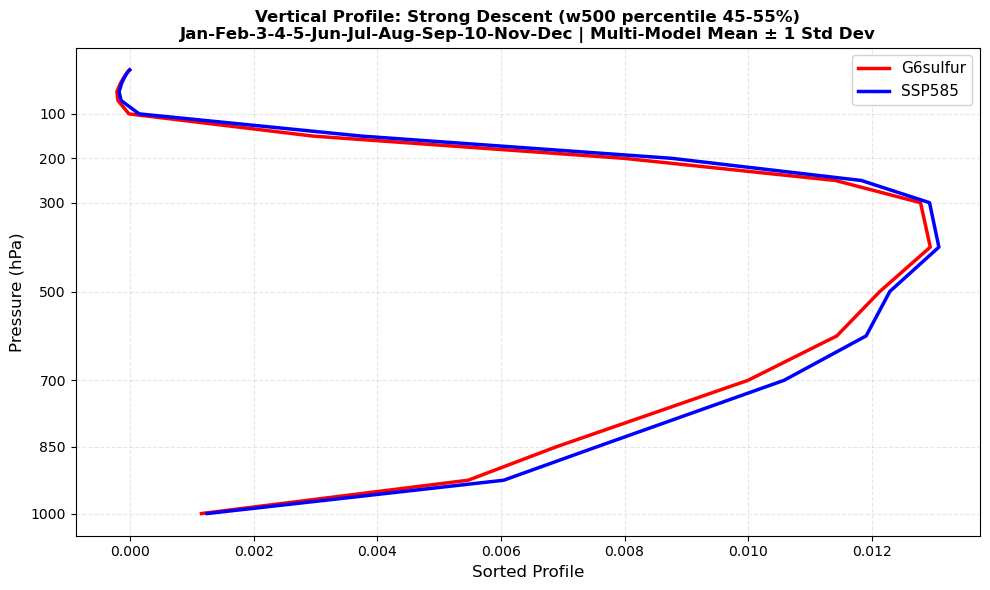

In [33]:
# Weak circulation (middle percentiles)
fig, ax = plot_sorted_profiles_comparison(
    ds_sorted,
    exp1=EXP1,
    exp2=EXP2,
    months=(1, 12),
    percentile_range=(45, 55),  # Weak circulation
)

In [34]:
def validate_sorting(ds_sorted, exp='G6sulfur', month=7):
    """
    Validate that sorting is working correctly.
    
    Should show:
    - Low percentiles (0-10): negative w500 (ascent)
    - High percentiles (90-100): positive w500 (descent)
    """
    import matplotlib.pyplot as plt
    
    # Get w500 percentile values for one model and experiment
    w500_vals = ds_sorted['w500_percentile'].sel(
        experiment=exp, 
        month=month
    ).isel(model=0)  # Just check first model
    
    percentiles = ds_sorted.percentile.values
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(percentiles, w500_vals, 'o-', linewidth=2)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='w500=0')
    ax.axvspan(0, 10, alpha=0.2, color='blue', label='Strong Ascent (should be negative)')
    ax.axvspan(90, 100, alpha=0.2, color='red', label='Strong Descent (should be positive)')
    
    ax.set_xlabel('Percentile', fontsize=12)
    ax.set_ylabel('w500 (Pa/s)', fontsize=12)
    ax.set_title(f'w500 values by percentile - {exp} - Month {month}\n'
                 f'Check: Low percentiles negative, High percentiles positive', 
                 fontsize=11)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{'='*60}")
    print(f"Validation for {exp}, Month {month}")
    print(f"{'='*60}")
    print(f"Percentile 0-10 (Strong Ascent):")
    print(f"  Mean w500: {w500_vals.sel(percentile=slice(0,10)).mean().values:.6f} Pa/s")
    print(f"  Should be NEGATIVE")
    print(f"\nPercentile 90-100 (Strong Descent):")
    print(f"  Mean w500: {w500_vals.sel(percentile=slice(90,100)).mean().values:.6f} Pa/s")
    print(f"  Should be POSITIVE")
    print(f"\nPercentile 50 (Median):")
    print(f"  w500: {w500_vals.sel(percentile=50).values:.6f} Pa/s")
    print(f"{'='*60}\n")

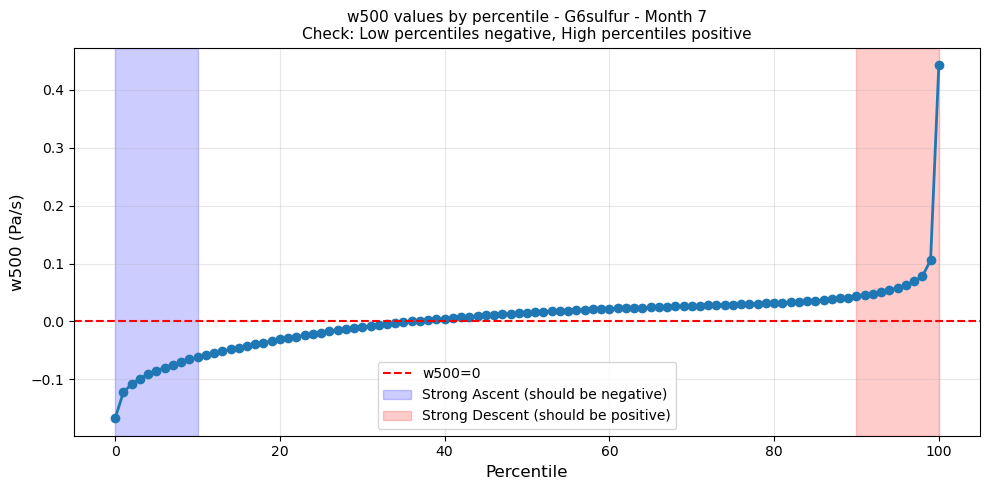


Validation for G6sulfur, Month 7
Percentile 0-10 (Strong Ascent):
  Mean w500: -0.093045 Pa/s
  Should be NEGATIVE

Percentile 90-100 (Strong Descent):
  Mean w500: 0.096085 Pa/s
  Should be POSITIVE

Percentile 50 (Median):
  w500: 0.015184 Pa/s



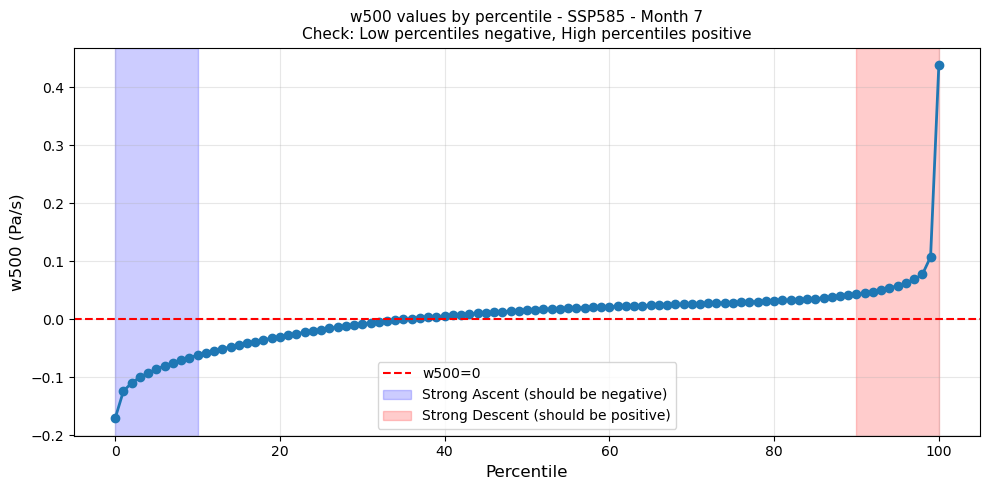


Validation for SSP585, Month 7
Percentile 0-10 (Strong Ascent):
  Mean w500: -0.094205 Pa/s
  Should be NEGATIVE

Percentile 90-100 (Strong Descent):
  Mean w500: 0.095584 Pa/s
  Should be POSITIVE

Percentile 50 (Median):
  w500: 0.015585 Pa/s



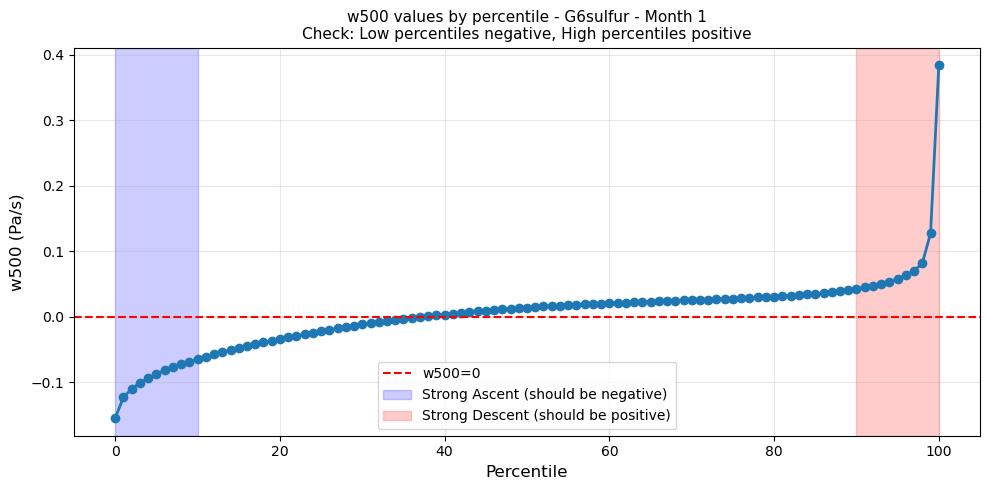


Validation for G6sulfur, Month 1
Percentile 0-10 (Strong Ascent):
  Mean w500: -0.093776 Pa/s
  Should be NEGATIVE

Percentile 90-100 (Strong Descent):
  Mean w500: 0.093049 Pa/s
  Should be POSITIVE

Percentile 50 (Median):
  w500: 0.014148 Pa/s



In [36]:
# ds_sorted = xr.open_dataset('Omega_sorted_G6sulfur_and_SSP245.nc')
ds_sorted = xr.open_dataset(output_file)


# Validate for different months
validate_sorting(ds_sorted, exp='G6sulfur', month=7)  # July
validate_sorting(ds_sorted, exp='SSP585', month=7)
validate_sorting(ds_sorted, exp='G6sulfur', month=1)  # January

In [37]:
def validate_sorting_with_profiles(ds_sorted, exp='G6sulfur', month=7):
    """
    Validate sorting by comparing w500 percentile values 
    with the actual sorted wap profiles at 500 hPa.
    
    They should match exactly if sorting is correct.
    """
    import matplotlib.pyplot as plt
    
    # Get w500 percentile values (what we sorted by)
    # Get w500 percentile values (what we sorted by)
    w500_percentile = ds_sorted['w500_percentile'].isel(model=0).sel(
        experiment=exp, 
        month=month
    )
    
    # Get sorted wap profiles at 500 hPa (what got sorted)
    sorted_wap_500 = ds_sorted['sorted_profile'].isel(model=0).sel(
        experiment=exp,
        month=month
    ).sel(plev=50000, method='nearest')
    
    percentiles = ds_sorted.percentile.values
    
    # Plot comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: Overlay both
    ax = axes[0]
    ax.plot(percentiles, w500_percentile, 'o-', linewidth=2, label='w500 (sorting key)', markersize=4)
    ax.plot(percentiles, sorted_wap_500, 's--', linewidth=2, alpha=0.7, 
            label='Sorted wap at 500hPa', markersize=3)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel('Percentile', fontsize=12)
    ax.set_ylabel('w500 (Pa/s)', fontsize=12)
    ax.set_title(f'Comparison: w500 vs Sorted Profile at 500hPa\n{exp} - Month {month}', fontsize=11)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Right: Difference
    ax = axes[1]
    difference = sorted_wap_500 - w500_percentile
    ax.plot(percentiles, difference, 'o-', linewidth=2, color='red')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax.set_xlabel('Percentile', fontsize=12)
    ax.set_ylabel('Difference (Pa/s)', fontsize=12)
    ax.set_title('Difference: Sorted Profile - w500\n(Should be near zero)', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    print(f"\n{'='*60}")
    print(f"Profile Sorting Validation: {exp}, Month {month}")
    print(f"{'='*60}")
    print(f"Max absolute difference: {np.abs(difference).max().values:.8f} Pa/s")
    print(f"Mean absolute difference: {np.abs(difference).mean().values:.8f} Pa/s")
    print(f"RMS difference: {np.sqrt((difference**2).mean()).values:.8f} Pa/s")
    print(f"\nIf sorting is correct, these should be ~0")
    print(f"{'='*60}\n")
    
    return difference

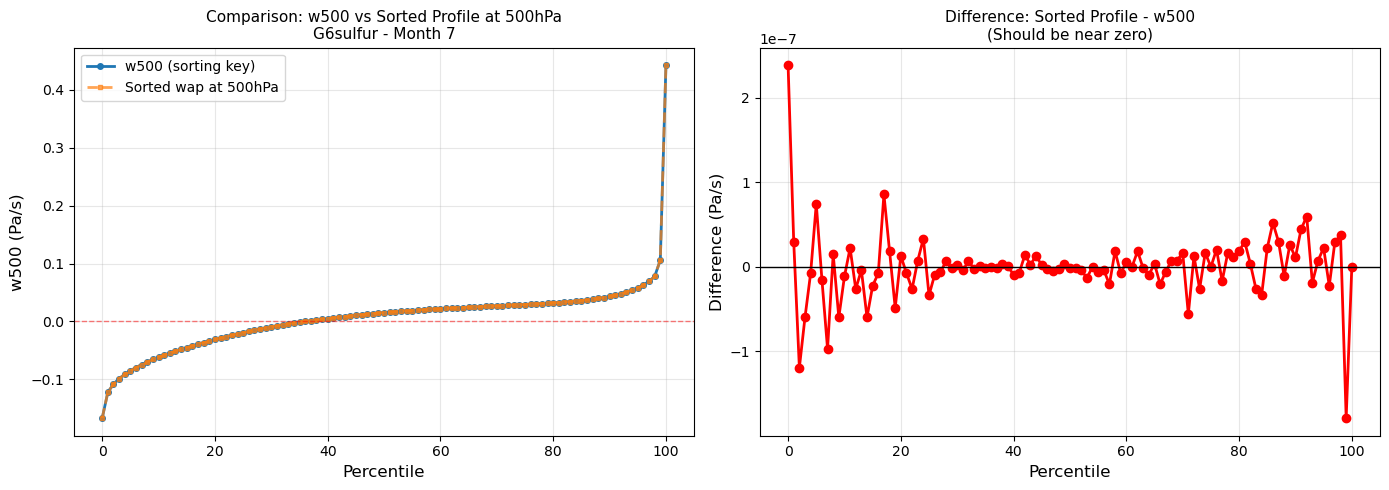


Profile Sorting Validation: G6sulfur, Month 7
Max absolute difference: 0.00000024 Pa/s
Mean absolute difference: 0.00000002 Pa/s
RMS difference: 0.00000004 Pa/s

If sorting is correct, these should be ~0



In [38]:
diff = validate_sorting_with_profiles(ds_sorted, exp='G6sulfur', month=7)

In [39]:
# Check what's in your dataset
print(list(ds_sorted.data_vars))
print(ds_sorted.sorted_profile.dims)

# If experiment is not a dimension, select differently
sorted_wap_500 = ds_sorted['sorted_profile'].isel(model=0).sel(
    month=7,
    plev=50000,
    method='nearest'
)

['sorted_profile', 'w500_percentile', 'count']
('model', 'experiment', 'month', 'percentile', 'plev')


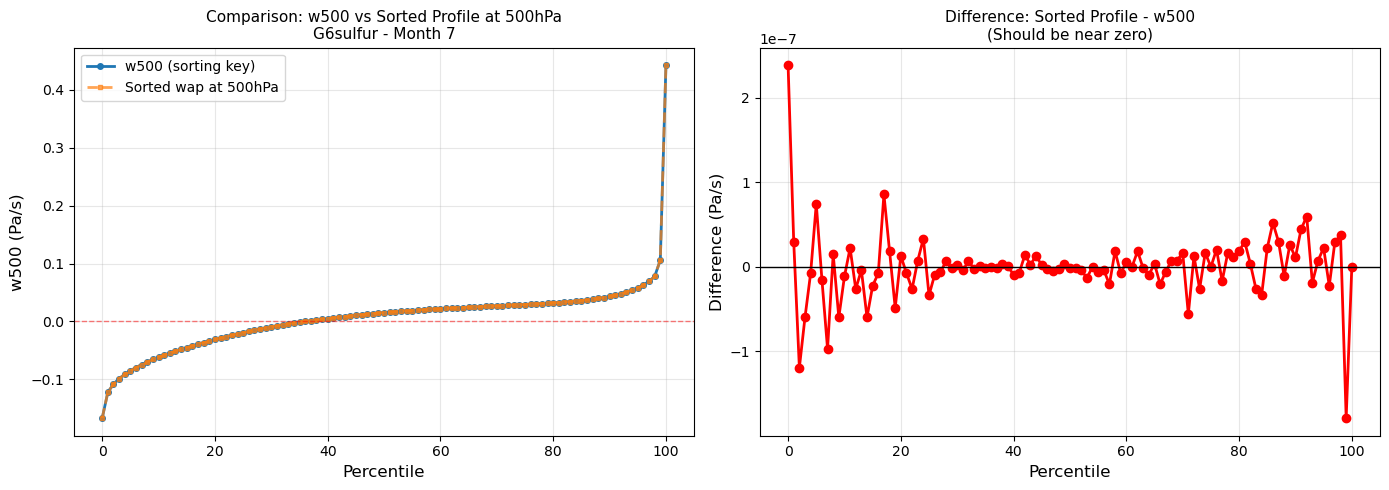


Profile Sorting Validation: G6sulfur, Month 7
Max absolute difference: 0.00000024 Pa/s
Mean absolute difference: 0.00000002 Pa/s
RMS difference: 0.00000004 Pa/s

If sorting is correct, these should be ~0



In [40]:
# ds_sorted = xr.open_dataset('Omega_sorted_G6sulfur_and_SSP245.nc')
ds_sorted = xr.open_dataset(output_file)


# This should now show very small differences (< 1e-6)
diff = validate_sorting_with_profiles(ds_sorted, exp='G6sulfur', month=7)